In [1]:
import pandas as pd
import os, sys, pickle

sys.path.insert(0,'..')
from functions.myfunctions import *
import functions.distancefunctions as df
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
distances_dir = '../data/outputs/'
f2 = '../data/output/figures/'

datalist1 = pd.read_csv('../data/tcrdb_export_cleaned_withseqs.csv', index_col=0).drop_duplicates(subset = ['pdb'], keep='first')

In [3]:
with open(distances_dir + 'interchain_mindists.pickle', 'rb') as handle:
    distances = pickle.load(handle)
    
with open(distances_dir + 'intrachain_a_mindists.pickle', 'rb') as handle:
    distances_a = pickle.load(handle)

with open(distances_dir + 'intrachain_b_mindists.pickle', 'rb') as handle:
    distances_b = pickle.load(handle)

In [4]:
cdr1_res = list(range(27, 39))
cdr1_res = [str(x) for x in cdr1_res]
cdr2_res = list(range(56, 66))
cdr2_res = [str(x) for x in cdr2_res]
cdr3_res = list(range(105,112)) + ['111A', '111B',
                        '111C', '111D', '111E', '111F', '112E', '112F', '112D', '112C', '112B', '112A', '112'] + list(range(113,118))
cdr3_res = [str(x) for x in cdr3_res]

Number of contacts at different thresholds

In [5]:
thresh = np.arange(2, 10.5, 0.5)
print(thresh)

thresh_contact_count_interchain = {}
thresh_contact_count_intrachain_a = {}
thresh_contact_count_intrachain_b = {}

for t in thresh:
    thresh_contact_count_interchain[t] = []
    thresh_contact_count_intrachain_a[t] = []
    thresh_contact_count_intrachain_b[t] = []
    
    for pdb in datalist1['pdb'].tolist():
        d_pdb = distances[pdb]
        pdb_3_3 = [x for x in d_pdb.keys() if (x[0] in cdr3_res) and (x[1] in cdr3_res) and (d_pdb[x] < t)]

        thresh_contact_count_interchain[t].append(len(pdb_3_3))

        d_pdb_a = distances_a[pdb]
        d_pdb_b = distances_b[pdb]
        pdb_1_3_a = [x for x in d_pdb_a.keys() if (x[0] in cdr1_res) and (x[1] in cdr3_res) and (d_pdb_a[x] < t)]
        pdb_1_3_b = [x for x in d_pdb_b.keys() if (x[0] in cdr1_res) and (x[1] in cdr3_res) and (d_pdb_b[x] < t)]

        thresh_contact_count_intrachain_a[t].append(len(pdb_1_3_a))
        thresh_contact_count_intrachain_b[t].append(len(pdb_1_3_b))

[ 2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5  7.   7.5  8.   8.5
  9.   9.5 10. ]


In [6]:
from scipy import stats

In [7]:
vals_inter = [np.mean(thresh_contact_count_interchain[t]) for t in thresh]
vals_intra_a = [np.mean(thresh_contact_count_intrachain_a[t]) for t in thresh]
vals_intra_b = [np.mean(thresh_contact_count_intrachain_b[t]) for t in thresh]

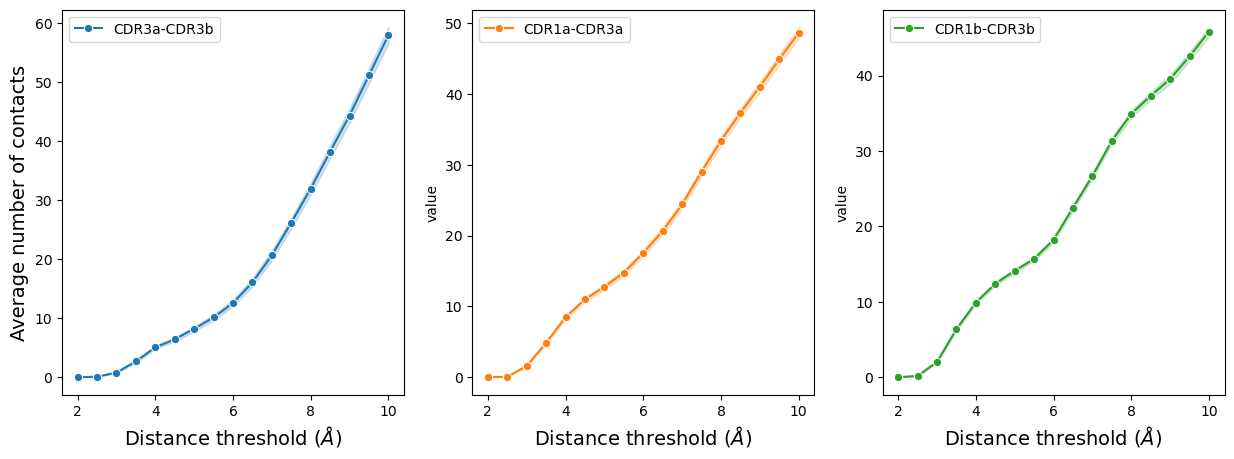

In [8]:
f, ax = plt.subplots(ncols = 3, figsize = (15,5))
labels = ['CDR3a-CDR3b', 'CDR1a-CDR3a', 'CDR1b-CDR3b']
colors = ['tab:blue', 'tab:orange', 'tab:green']

for j, vals in enumerate([thresh_contact_count_interchain, thresh_contact_count_intrachain_a, thresh_contact_count_intrachain_b]):

    X = pd.DataFrame(vals).T.reset_index().melt(id_vars='index')
    X['index'] = X['index'].astype(float)

    sns.lineplot(X, x = 'index', y = 'value', errorbar=('ci',95), 
                 ax = ax[j], label = labels[j], c = colors[j], marker='o')
    ax[j].set_xlabel(r'Distance threshold ($\AA$)', fontsize = 14)
ax[0].set_ylabel('Average number of contacts', fontsize = 14)
plt.legend()
plt.savefig(f2 + 'number_of_contacts_vs_threshold.pdf', bbox_inches = 'tight')
plt.show()